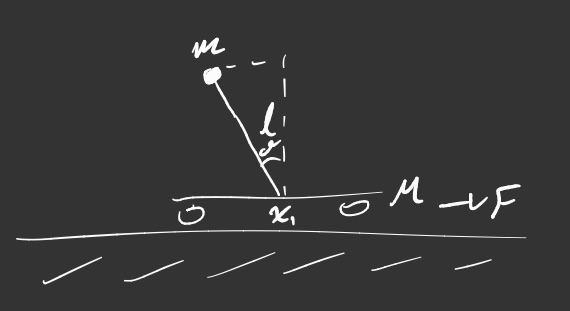

# State-Space Control of an Inverted Pendulum-Cart System
**Author:** Kevin Goguen  
**Project Type:** Dynamic System Modeling, LQR Control Loop Design, & Numerical Simulation  

---

## Quick-Scan Project Summary

* **Objective:** Developed a complete state-space simulation and optimal control loop to actively stabilize an unstable, non-linear inverted pendulum-cart system.
* **Industrial Relevance:** Validated foundational controls frameworks used in  bipedal robotic balancing and automated crane anti-sway systems.
* **Core Technologies:** Python (`numpy`, `scipy`, `control`, `ipycanvas`), State-Space Modeling, Linear-Quadratic Regulator (LQR) Synthesis, 4th-Order Runge-Kutta (RK4) Numeric Integration.
* **Design Constraint Realized:** Configured multi-variable optimization matrices ($Q, R$) to satisfy strict safety margins, bounding linear track deviation to within $\pm1.0\text{ meter}$ during severe disturbance rejection.

---

## System Modeling & Control Loop Design

### 1. State-Space Representation
The system monitors linear track displacement, cart velocity, pendulum angular deviation from vertical, and angular velocity:

$$\vec{x} = [\theta, \dot{\theta}, x_1, \dot{x_1}]^T$$

The highly coupled, non-linear system equations derived via Lagrangian mechanics are linearized about the unstable equilibrium point ($\theta \approx 0, \dot{\theta} \approx 0$) to establish the state-space matrices ($A$ and $B$):

$$\dot{\vec{x}} = A\vec{x} + B\vec{u}$$

$$\begin{bmatrix} \dot{\theta} \\ \ddot{\theta} \\ \dot{x} \\ \ddot{x}\end{bmatrix} \approx \begin{bmatrix}
0 & 1 & 0 & 0 \\
\left(1+\frac{m}{M}\right)\frac{g}{l} & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
-\frac{m}{M}g & 0 & 0 & 0
\end{bmatrix}
\begin{bmatrix} \theta \\ \dot{\theta} \\ x \\ \dot{x} \end{bmatrix} + \begin{bmatrix} 0 \\ -\frac{1}{Ml} \\ 0 \\ \frac{1}{M} \end{bmatrix}F$$

### 2. Linear-Quadratic Regulator (LQR) Synthesis
To calculate the optimal feedback gain matrix $K$ ($\vec{u} = -K\vec{x}$), the Infinite-Horizon cost function $J$ is minimized:

$$J = \int^\infty_0\left(\vec{x}^TQ\vec{x}+\vec{u}^TR\vec{u}\right)dt$$

The unique positive-definite solution matrix $S$ is solved using the **Algebraic Riccati Equation (ARE)** via the `python-control` library:

$$SA + A^TS - SB^TR^{-1}BS + Q = 0 \quad \Rightarrow \quad K = R^{-1}B^TS$$

### 3. Controller Tuning & Penalties
To satisfy the physical system boundary constraint (linear track limits under $1.0\text{ m}$), the state-weighting penalty matrix $Q$ was biased heavily on the linear displacement diagonal element ($Q_{33} = 50$), balancing positional correction against standard actuator expenditure limits ($R = 1$):

$$Q = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 50 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \quad R = 1$$

---

## Non-Linear Plant Simulation (Digital Twin)

Because analytical solutions to the true coupled system equations are non-existent, this project implements a **4th-Order Runge-Kutta (RK4) integration engine** to step the physical plant forward in time. This creates an authentic "Digital Twin" simulation benchmark to test the linear controller against full non-linear physical dynamics.

$$\vec{x}(t + h) \approx \vec{x}(t) + \frac{h}{6}\left(\vec{k}_1 + 2\vec{k}_2 + 2\vec{k}_3 + \vec{k}_4\right)$$

---

## Deep Dive: Academic Analysis & Theoretical Background

##Project Overview & System Modeling

This project seeks to simulate the dynamics of a controlled inverted cart-pendulum system in state space. It does so by simulating the effects of a control force on the cart at the base of the pendulum as it seeks to restore the pendulum to an upright position. This project also uses standard methods to optimize the control force, with consideration of the energy expenditure of the actuator. This system may be used to model a variety of modern automation applications, such as robotic arm stabilization.

The position and velocity of the cart, as well as the angular position and angular velocity of the bob are considered. The state vector $\vec{x}$ is defined as follows.

$$\vec{x} = [\theta, \dot{\theta}, x_1, \dot{x_1}]$$

Below are the equations of motion for this system, derived by the application of lagrangian mechanics.

$$\ddot{\theta} = \frac{gsin\theta - cos\theta\left(\frac{F + ml\dot{\theta}^2sin\theta}{M+m}\right)}{l\left(1 - \frac{mcos^2\theta}{M+m}\right)}$$

$$\ddot{x}_1 = \frac{F + ml\dot{\theta}^2sin\theta - ml\ddot{\theta}cos\theta}{M+m}$$

The control force is modeled as being inversely proportional to the deviation from the desired state. It is written as follows.

$$F = -K_{\theta}Δ\theta - K_{\dot{\theta}}Δ\dot{\theta} - K_{x}Δx - K_{\dot{x}}Δ\dot{x}$$

The control force optimization parameters are calculated through the use of a Linear-Quadratic Regulator. Since the equations of motion are highly non-linear, they are linearized for small $\theta$ and $\dot{\theta}$. The intent of this system is to maintain the upright position of the pendulum and, therefore, this linearization scheme should work reasonably well for reasonably small deviations from the desired state.

$\theta \approx 0, \dot{\theta} \approx 0:$

$$\ddot{\theta} \approx \left(1+\frac{m}{M}\right)\frac{g}{l}\theta - \frac{F}{Ml}$$

$$\ddot{x} \approx - \frac{m}{M}g\theta + \frac{F}{M}$$

The dynamics of the system are more closely approximated by numerical integration of the equations of motion via the fourth-order Runge-Kutta method. This is necessary due to the highly non-linear, coupled nature of these equations, forbidding an analytical solution.

##Section II: Control Loop Design (LQR Optimization)

The goal here is to optimize the system such that there is a balance between position and actuator energy expenditure. This project uses linear-quadratic regulation, assumes the standard definition of the cost function $J$.

$$J = \int^\infty_0\left(\vec{x}^TQ\vec{x}+\vec{u}^TR\vec{u}\right)dt$$

Where $\vec{x}$ is the state of our system and $\vec{u}$ is the control force vector. The Q and R matrices are used to determine how the cost of deviations in different state variables are weighted. These can be changed by the implementing engineer to fit the desired constraints of the system. Larger components of Q, punish state deviations, while larger R components punish actuator energy consumption. As these considerations are highly situational, there is no perfect method for determining them. It has been shown that the optimal form of the standard cost function $J^*$ is quadratic in $\vec{x}$.

$$J^* = \vec{x}^TS\vec{x}$$

This method assumes a linear system, with dynamics characterized by the following equation.

$$\dot{\vec{x}}=A\vec{x}+B\vec{u}$$

A and B are the component matrices of our system's state and control force vectors respectively. The particular form of this equation may be found, using the linearizations of our equations of motion.

$$\dot{\vec{x}} = \begin{bmatrix} \dot{\theta} \\ \ddot{\theta} \\ \dot{x} \\ \ddot{x}\end{bmatrix} \approx \begin{bmatrix} \dot{\theta} \\ \left(1+\frac{m}{M}\right)\frac{g}{l} - \frac{F}{Ml} \\ \dot{x} \\ - \frac{m}{M}g\theta + \frac{F}{M} \end{bmatrix} = \begin{bmatrix}
0 & 1 & 0 & 0 \\
\left(1+\frac{m}{M}\right)\frac{g}{l} & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
-\frac{m}{M}g & 0 & 0 & 0
\end{bmatrix}
\begin{bmatrix} \theta \\ \dot{\theta} \\ x \\ \dot{x} \end{bmatrix} + \begin{bmatrix} 0 \\ -\frac{1}{Ml} \\ 0 \\ \frac{1}{M} \end{bmatrix}F = A\vec{x} + B\vec{u}$$

We now have the form of the A and B matrices for our system.

$$A = \begin{bmatrix}
0 & 1 & 0 & 0 \\
\left(1+\frac{m}{M}\right)\frac{g}{l} & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
-\frac{m}{M}g & 0 & 0 & 0
\end{bmatrix}, \space\space\space B = \begin{bmatrix} 0 \\ -\frac{1}{Ml} \\ 0 \\ \frac{1}{M} \end{bmatrix}$$

We would like to minimize the the cost of this system. The problem of optimizing the standard cost function is solved by the Algebraic Ricatti Equation (ARE).

Algebraic Ricatti Equation:

$$SA + A^TS - SB^TR^{-1}BS + Q = 0$$

According to Bellman's Principle of Optimality, the cost function is minimized by the following equation.

$$\frac{\partial}{\partial \vec{u}}\left[\vec{x}^TQ\vec{x} + \vec{u}^TR\vec{u} + \frac{\partial J^*}{\partial \vec{x}}(A\vec{x} + B\vec{u} - \dot{\vec{x}})\right] = 0$$

Simplifying this by inserting $\frac{\partial J^*}{\partial \vec{x}}$ and taking partials with respect to $\vec{u}$ allows us to determine the form of the optimal control force vector.

$$\frac{\partial J^*}{\partial \vec{x}} = 2\vec{x}^TS \Rightarrow 2\vec{u}^TR + 2\vec{x}^TSB = 0$$

$$\Rightarrow \vec{u} = -R^{-1}B^TS\vec{x}$$

$$K \equiv R^{-1}B^TS \Rightarrow \vec{u} = K\vec{x}$$

With this, it is clear that we must solve the ARE for S to arrive at the optimal control force for this system. This project utilizes the control.lqr method from the python-control library to solve the ARE numerically.

##Section III: Controller Tuning & Physical Constraints

When selecting values for Q and R, the intent was to keep the cart from deviating more than one meter from it's initial position. With this retriction in mind, the following matrices were constructed.

$$Q = \begin{bmatrix} 1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 50 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}, \space\space\space R = 1$$

The heavy weighting for $Q_{33}$ heavily punishes deviations in $x$.

##Section IV: Plant Simulation & Testing (Digital Twin Architecture)

Since LQR requires an approximation of the state dynamics of the system, it would be useful to simulate the time-evolution of our system to determine if this approximation converges sufficiently to produce adequate control force parameters. Unfortunately, the equations of motion for this system are impossible to solve analytically. Therefore, a numerical approximation is necessary. This project elects to implement the fourth-order Runge-Kutta method of numerical integration to meet this demand. The implementation is outlined below.

$$\frac{\partial \vec{x}}{\partial t} \equiv \vec{f}$$

$$\vec{x}(\theta, \dot{\theta}, x, \dot{x}, t + h) \approx \vec{x}(\theta, \dot{\theta}, x, \dot{x}, t) + \frac{h}{6}\left(\vec{k}_1 + 2\vec{k}_2 + 2\vec{k}_3 + \vec{k}_4\right)$$

where

$$h = \Delta t$$

$$\vec{k}_1 = \vec{f}(\theta_0, \dot{\theta}_0, x, \dot{x}_0)$$

$$\vec{k}_2 = \vec{f}\left(\theta_0 + \frac{h}{2}k_{1,\theta}, \dot{\theta}_0 + \frac{h}{2}k_{1,\dot{\theta}}, x_0 + \frac{h}{2}k_{1,x}, \dot{x}_0 + \frac{h}{2}k_{1,\dot{x}}\right)$$

$$\vec{k}_3 = \vec{f}\left(\theta_0 + \frac{h}{2}k_{2,\theta}, \dot{\theta}_0 + \frac{h}{2}k_{2,\dot{\theta}}, x_0 + \frac{h}{2}k_{2,x}, \dot{x}_0 + \frac{h}{2}k_{2,\dot{x}}\right)$$

$$\vec{k}_4 = \vec{f}\left(\theta_0 + hk_{3,\theta}, \dot{\theta}_0 + hk_{3,\dot{\theta}}, x_0 + hk_{3,x}, \dot{x}_0 + hk_{3,\dot{x}}\right)$$

# State-Space Control & Digital Twin Simulation of an Inverted Pendulum-Cart System
**Author:** Kevin Goguen  
**Project Focus:** State-Space Modeling, LQR Synthesis, Dynamic Simulation & Parameter Robustness  

---

## Project Overview & Engineering Specifications

### Objective
This project implements a continuous state-space modeling framework and an optimal control loop to actively stabilize an inherently unstable, non-linear inverted pendulum-cart system.

### Industrial Relevance
The state-space architectures and optimization methodologies executed here serve as the baseline tracking framework for modern multi-variable industrial applications, including:
* **Robotics:** Dynamic balancing loops for bipedal and humanoid mobility platforms.
* **Material Handling:** Active anti-sway crane control systems in automated shipping yards.

### Core Technology Stack
* **Languages & Core Libraries:** Python (`numpy`, `scipy`, `control`)
* **Simulation Visualizations:** `ipycanvas`, `matplotlib`
* **Control Systems Architecture:** Continuous State-Space Modeling, Linear-Quadratic Regulator (LQR) Optimal Control Synthesis
* **Numerical Methods:** Self-implemented 4th-Order Runge-Kutta (RK4) integration engine

---

## System Modeling & Control Loop Design

### 1. State-Space Formulation
The system monitors linear track displacement ($x$), linear cart velocity ($\dot{x}$), pendulum angular deviation from vertical ($\theta$), and angular velocity ($\dot{\theta}$):

$$\vec{x} = [\theta, \dot{\theta}, x, \dot{x}]^T$$

The highly coupled, non-linear system equations of motion derived via Lagrangian mechanics are linearized about the unstable upper equilibrium point ($\theta \approx 0, \dot{\theta} \approx 0$) to construct the continuous state-space matrices ($A$ and $B$):

$$\dot{\vec{x}} = A\vec{x} + B\vec{u}$$

$$\begin{bmatrix} \dot{\theta} \\ \ddot{\theta} \\ \dot{x} \\ \ddot{x}\end{bmatrix} \approx \begin{bmatrix}
0 & 1 & 0 & 0 \\
\left(1+\frac{m}{M}\right)\frac{g}{l} & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
-\frac{m}{M}g & 0 & 0 & 0
\end{bmatrix}
\begin{bmatrix} \theta \\ \dot{\theta} \\ x \\ \dot{x} \end{bmatrix} + \begin{bmatrix} 0 \\ -\frac{1}{Ml} \\ 0 \\ \frac{1}{M} \end{bmatrix}F$$

### 2. Optimal Feedback Synthesis (LQR)
To track system deviations and minimize structural error, an optimal feedback gain matrix $K$ is derived via negative state feedback ($\vec{u} = -K\vec{x}$). The gain minimizes the infinite-horizon continuous cost function $J$:

$$J = \int^\infty_0\left(\vec{x}^TQ\vec{x}+\vec{u}^TR\vec{u}\right)dt$$

The unique positive-definite solution matrix $S$ is solved via the continuous **Algebraic Riccati Equation (ARE)** using the `python-control` library:

$$SA + A^TS - SB^TR^{-1}BS + Q = 0 \quad \Rightarrow \quad K = R^{-1}B^TS$$

### 3. Controller Tuning & Physical Constraints
* **Design Constraint:** The cart must remain within a physical rail safety boundary of **$\pm1.0\text{ meter}$** during tracking and disturbance rejection.
* **Tuning Matrix Rationale:** To satisfy this constraint, the state penalty matrix $Q$ is heavily biased on the linear displacement diagonal element ($Q_{33} = 50$). This penalizes spatial travel tightly while balancing standard actuator effort penalties ($R = 1$):

$$Q = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 50 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \quad R = 1$$

---

## Non-Linear Plant Simulation (Digital Twin)

Because analytical solutions to the true coupled system equations are non-existent, this project implements a **4th-Order Runge-Kutta (RK4) numerical integration engine** to step the physical plant forward in time ($h = \Delta t$).

This architecture constructs an authentic "Digital Twin" pipeline: the optimal LQR controller—designed using a *simplified, linear approximation*—is forced to regulate the *true, non-linear, coupled* physical equations of motion.

$$\vec{x}(t + h) \approx \vec{x}(t) + \frac{h}{6}\left(\vec{k}_1 + 2\vec{k}_2 + 2\vec{k}_3 + \vec{k}_4\right)$$

---

## Deep Dive: Theoretical Background & Mathematical Derivations

### Non-Linear Plant Physics
Applying Lagrangian mechanics to the cart-pendulum system yields the following exact non-linear equations of motion:

$$\ddot{\theta} = \frac{g\sin\theta - \cos\theta\left(\frac{F + ml\dot{\theta}^2\sin\theta}{M+m}\right)}{l\left(1 - \frac{m\cos^2\theta}{M+m}\right)}$$

$$\ddot{x} = \frac{F + ml\dot{\theta}^2\sin\theta - ml\ddot{\theta}\cos\theta}{M+m}$$

Assuming small angle approximations ($\theta \approx 0, \dot{\theta} \approx 0$) for linearization yields:

$$\ddot{\theta} \approx \left(1+\frac{m}{M}\right)\frac{g}{l}\theta - \frac{F}{Ml}$$

$$\ddot{x} \approx - \frac{m}{M}g\theta + \frac{F}{M}$$

### Derivation of the Matrix State Equations
By mapping the linearized scalar differentials back to state vector definitions, the system dynamics are isolated into explicit matrix form:

$$\dot{\vec{x}} = \begin{bmatrix} \dot{\theta} \\ \ddot{\theta} \\ \dot{x} \\ \ddot{x}\end{bmatrix} \approx \begin{bmatrix} \dot{\theta} \\ \left(1+\frac{m}{M}\right)\frac{g}{l}\theta - \frac{F}{Ml} \\ \dot{x} \\ - \frac{m}{M}g\theta + \frac{F}{M} \end{bmatrix} = A\vec{x} + B\vec{u}$$

### Cost Optimization via Bellman's Principle of Optimality
Assuming the optimal cost-to-go function $J^*$ is quadratic in state ($J^* = \vec{x}^TS\vec{x}$), Bellman's tracking partials are minimized with respect to control vector $\vec{u}$:

$$\frac{\partial}{\partial \vec{u}}\left[\vec{x}^TQ\vec{x} + \vec{u}^TR\vec{u} + \frac{\partial J^*}{\partial \vec{x}}(A\vec{x} + B\vec{u} - \dot{\vec{x}})\right] = 0$$

$$\frac{\partial J^*}{\partial \vec{x}} = 2\vec{x}^TS \implies 2\vec{u}^TR + 2\vec{x}^TSB = 0 \implies \vec{u} = -R^{-1}B^TS\vec{x}$$

### RK4 Derivative Vector Stepping Function
The time-evolution function $\frac{\partial \vec{x}}{\partial t} \equiv \vec{f}$ updates intermediate vector fields $\vec{k}_n$ across step width $h$:

$$\vec{k}_1 = \vec{f}(\theta_0, \dot{\theta}_0, x_0, \dot{x}_0)$$

$$\vec{k}_2 = \vec{f}\left(\theta_0 + \frac{h}{2}k_{1,\theta}, \dot{\theta}_0 + \frac{h}{2}k_{1,\dot{\theta}}, x_0 + \frac{h}{2}k_{1,x}, \dot{x}_0 + \frac{h}{2}k_{1,\dot{x}}\right)$$

$$\vec{k}_3 = \vec{f}\left(\theta_0 + \frac{h}{2}k_{2,\theta}, \dot{\theta}_0 + \frac{h}{2}k_{2,\dot{\theta}}, x_0 + \frac{h}{2}k_{2,x}, \dot{x}_0 + \frac{h}{2}k_{2,\dot{x}}\right)$$

$$\vec{k}_4 = \vec{f}\left(\theta_0 + hk_{3,\theta}, \dot{\theta}_0 + hk_{3,\dot{\theta}}, x_0 + hk_{3,x}, \dot{x}_0 + hk_{3,\dot{x}}\right)$$

In [3]:
!pip install control
!pip install ipycanvas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.3 MB/s eta 0:00:00


In [1]:
from google.colab import output
output.enable_custom_widget_manager()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import control as ct
from time import sleep
from ipycanvas import Canvas, hold_canvas

In [5]:
# Created by: Kevin Goguen
# Date created: August 27, 2026

class CartPendulumSim:

  def __init__(self, m = 1.0, M = 1.0, l = 0.25, state = None):
    # Physical system physical parameters
    self.m = m      # Mass of the pendulum bob (kg)
    self.M = M      # Mass of the motorized cart (kg)
    self.l = l      # Structural length of the pendulum rod (meters)

    # Initial state telemetry tracking: [angle, angular_velocity, position, linear_velocity]
    self.state = state if state is not None else [0.5, 0.0, 0.0, 0.0]
    self.g = sp.constants.g  # Acceleration due to gravity (m/s^2)
    self.gains = self.lqr_control()

  def control_force(self, state):
    """Calculates the scalar corrective restoring force (Newtons) applied to the cart base."""
    # Unpack control feedback gain matrix coefficients
    k_theta, k_theta_dot, k_x, k_x_dot = self.gains[0], self.gains[1], self.gains[2], self.gains[3]

    # Unpack physical state telemetry
    theta, theta_dot, x, x_dot = state[0], state[1], state[2], state[3] # Extracts state variables

    # Calculate linear negative state-feedback control action
    force = -(k_theta * theta + k_theta_dot * theta_dot + k_x * x + k_x_dot * x_dot) # Final calcuation

    return force

  def lqr_control(self):
    '''Solves the continuous Algebraic Riccati Equation to calculate stable optimal control gains.'''
    # State-Space System Matrix A (Linearized physical plant dynamics)
    A = np.array([[0, 1, 0, 0],
                 [(1 + self.m/self.M) * (self.g/self.l), 0, 0, 0],
                 [0, 0, 0, 1],
                 [-(self.m/self.M) * self.g, 0, 0, 0]])

    # State-Space Input Matrix B (Actuator mapping matrix)
    B = np.array([[0],
                  [-1/(self.M * self.l)],
                  [0],
                  [1/self.M]])

    # Optimization State-Error Penalty Matrix Q
    # Scaled heavily at Q[2,2] to enforce safe linear track travel constraints
    Q = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0, 0, 50, 0],
                 [0, 0, 0, 1]])

    # Actuator Energy Cost Factor R
    R = 1

    # Synthesize state feedback gain matrix via python-control
    K, S, E = ct.lqr(A, B, Q, R)

    return [K[0][0], K[0][1], K[0][2], K[0][3]]

  def ang_acc(self, theta, theta_dot, F):
    '''Calculates the magnitude of the pendulum's angular acceleration.'''
    numerator = self.g * np.sin(theta) - np.cos(theta) * ((F + self.m * self.l * (theta_dot**2) * np.sin(theta)) / (self.M + self.m))
    denominator = self.l * (1 - (self.m * (np.cos(theta)**2)) / (self.M + self.m))

    return numerator / denominator

  def acc(self, theta, theta_dot, theta_ddot, F):
    '''Calculates the magnitude of the cart's acceleration.'''
    acceleration = (F + self.m * self.l * (theta_dot**2) * np.sin(theta) - self.m * self.l * theta_ddot * np.cos(theta)) / (self.M + self.m)

    return acceleration

  def step(self, h):
    '''Performs the fourth-order Runge-Kutte approximation for one time step h.'''
    theta, theta_dot, x, x_dot = self.state[0], self.state[1], self.state[2], self.state[3] # Extracts state parameters.
    force = self.control_force(self.state) # Calculates force for current state.
    theta_ddot = self.ang_acc(theta, theta_dot, force) # Calculates current angular acceleration.
    x_ddot = self.acc(theta, theta_dot, theta_ddot, force) # Calculates current cart acceleration.

    # Instantiates first k-vector.
    k1 = [theta_dot, theta_ddot, x_dot, x_ddot]

    # Calculates first intermediate approximation for state parameters.
    theta_mid1 = theta + h*k1[0]/2
    theta_dot_mid1 = theta_dot + h*k1[1]/2
    x_mid1 = x + h*k1[2]/2
    x_dot_mid1 = x_dot + h*k1[3]/2

    # Intantiates first intermediate state approximation vector.
    state_mid1 = [theta_mid1, theta_dot_mid1, x_mid1, x_dot_mid1]

    # Calculates first intermediate force, angular acceleration, and cart acceleration.
    force_mid1 = self.control_force(state_mid1)
    theta_ddot_mid1 = self.ang_acc(theta_mid1, theta_dot_mid1, force_mid1)
    x_ddot_mid1 = self.acc(theta_mid1, theta_dot_mid1, theta_ddot_mid1, force_mid1)

    # Instantiates second k-vector.
    k2 = [theta_dot_mid1, theta_ddot_mid1, x_dot_mid1, x_ddot_mid1]

    # Calculates second intermediate approximation for state parameters.
    theta_mid2 = theta + h*k2[0]/2
    theta_dot_mid2 = theta_dot + h*k2[1]/2
    x_mid2 = x + h*k2[2]/2
    x_dot_mid2 = x_dot + h*k2[3]/2

    # Intantiates second intermediate state approximation vector.
    state_mid2 = [theta_mid2, theta_dot_mid2, x_mid2, x_dot_mid2]

    # Calculates second intermediate force, angular acceleration, and cart acceleration.
    force_mid2 = self.control_force(state_mid2)
    theta_ddot_mid2 = self.ang_acc(theta_mid2, theta_dot_mid2, force_mid2)
    x_ddot_mid2 = self.acc(theta_mid2, theta_dot_mid2, theta_ddot_mid2, force_mid2)

    # Instantiates third k-vector.
    k3 = [theta_dot_mid2, theta_ddot_mid2, x_dot_mid2, x_ddot_mid2]

    # Calculates endpoint approximation for state parameters.
    theta_end = theta + h*k3[0]
    theta_dot_end = theta_dot + h*k3[1]
    x_end = x + h*k3[2]
    x_dot_end = x_dot + h*k3[3]

    # Intantiates endpoint state approximation vector.
    state_end = [theta_end, theta_dot_end, x_end, x_dot_end]

    # Calculates endpoint force, angular acceleration, and cart acceleration.
    force_end = self.control_force(state_end)
    theta_ddot_end = self.ang_acc(theta_end, theta_dot_end, force_end)
    x_ddot_end = self.acc(theta_end, theta_dot_end, theta_ddot_end, force_end)

    # Instantiates fourth k-vector.
    k4 = [theta_dot_end, theta_ddot_end, x_dot_end, x_ddot_end]

    # Calculates RK4 time-step state vector.
    state_new = [theta + h*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])/6,
                 theta_dot + h*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])/6,
                 x + h*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2])/6,
                 x_dot + h*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3])/6]

    # Updates object state to RK4 time-stepped state
    self.state = state_new
    return force

In [58]:
def Present(sim):
  '''Plots all four state parameters, given simulation object and state.'''

  # Instantiates discretized time-axis.
  t_i = 0
  t_f = 5
  N = 1000
  t = np.linspace(t_i, t_f, N)
  h = t[1] - t[0]

  # Instantiates empty array to be filled with y-axis data for state parameters.
  history = [[], [], [], []]
  force_history = []

  # Populates history array with angular position, angular deviation, cart position, and cart velocity at each time step
  for i in range(N):
    force_history.append(sim.step(h)) # Calls RK4 function for given simulation.

    # Appends y-axis data to history array.
    history[0].append(sim.state[0])
    history[1].append(sim.state[1])
    history[2].append(sim.state[2])
    history[3].append(sim.state[3])

  # Animation
  #
  # Scale Factors:
  #   1 pixel = 1 mm <==> 1 m = 500 pixels

  m_to_p = 500

  bg_height = (sim.l * 2) * m_to_p
  bg_width = 2 * m_to_p

  canvas = Canvas(width=bg_width, height=bg_height)
  display(canvas)

  steps = len(history[0])

  with hold_canvas(canvas):
    for i in range(steps):

      canvas.clear()
      canvas.set_transform(1, 0, 0, 1, 0, 0)

      canvas_x_origin = bg_width / 2
      canvas_y_origin = bg_height

      # Draw Background
      canvas.fill_style = 'white'
      canvas.fill_rect(0, 0, bg_width, bg_height)

      # Draw Cart
      cart_width = 0.1 * m_to_p
      cart_height = 0.05 * m_to_p
      cart_x_origin = canvas_x_origin - cart_width / 2
      cart_y_origin = canvas_y_origin - cart_height - 10

      canvas.save()
      canvas.translate(cart_x_origin + history[2][i] * m_to_p, cart_y_origin)
      canvas.fill_style = 'blue'
      canvas.fill_rect(0, 0, cart_width, cart_height)
      canvas.restore()

      # Draw Pole
      pole_width = 0.005 * m_to_p
      pole_height = sim.l * m_to_p
      pole_x_origin = canvas_x_origin - pole_width / 2
      pole_y_origin = canvas_y_origin - cart_height

      canvas.save()
      canvas.translate(pole_x_origin + history[2][i] * m_to_p, pole_y_origin)
      canvas.rotate(history[0][i])
      canvas.scale(1, -1)
      canvas.fill_style = 'red'
      canvas.fill_rect(0, 0, pole_width, pole_height)
      canvas.restore()

      # Draw Bob
      bob_radius = 5
      bob_x_origin = pole_x_origin + pole_width / 2
      bob_y_origin = pole_y_origin - pole_height

      canvas.save()
      canvas.translate(bob_x_origin + (pole_height * np.sin(history[0][i])) + history[2][i] * m_to_p, bob_y_origin + pole_height * (1 - np.cos(history[0][i])))
      canvas.fill_style = 'green'
      canvas.fill_circle(0, 0, bob_radius)
      canvas.restore()

      canvas.sleep(h * 1000)

  sleep(t_f - t_i)

  fig, ax = plt.subplots(3, 2, figsize=(16, 9))

  gains = sim.gains
  fig.suptitle('K1 = ' + str(round(gains[0], 2)) + ', K1 = ' + str(round(gains[1], 2)) + ', K3 = ' + str(round(gains[2], 2)) + ', K4 = ' + str(round(gains[3], 2)))

  # plots pendulum's angular deviation in the top left quadrant
  ax[0, 0].plot(t, history[0], 'r')
  ax[0, 0].set_title('Angular Deviation')
  ax[0, 0].set_xlabel('Time (s)')
  ax[0, 0].set_ylabel('rad')
  ax[0, 0].grid()

  # plots pendulum's anglular velocity in the bottom left quadrant
  ax[1, 0].plot(t, history[1])
  ax[1, 0].set_title('Angular Velocity')
  ax[1, 0].set_xlabel('Time (s)')
  ax[1, 0].set_ylabel('rad/s')
  ax[1, 0].grid()

  # plots cart position in the top right quadrant
  ax[0, 1].plot(t, history[2], 'g')
  ax[0, 1].set_title('Cart Position')
  ax[0, 1].set_xlabel('Time (s)')
  ax[0, 1].set_ylabel('m')
  ax[0, 1].grid()

  # plots cart velocity in the bottom right quadrant
  ax[1, 1].plot(t, history[3], 'y')
  ax[1, 1].set_title('Cart Velocity')
  ax[1, 1].set_xlabel('Time (s)')
  ax[1, 1].set_ylabel('m/s')
  ax[1, 1].grid()

  ax[2, 0].axis('off')

  metrics = [
    ['Initial Angle', f'{history[0][0]:.3f} rad'],
    ['Final Angle', f'{history[0][-1]:.5f} rad'],
    ['Max Angle', f'{np.max(np.abs(history[0])):.3f} rad'],
    ['Max Cart Position', f'{np.max(np.abs(history[2])):.3f} m'],
    ['Max Cart Velocity', f'{np.max(np.abs(history[3])):.3f} m/s'],
    ['Peak Control Force', f'{np.max(np.abs(force_history)):.3f} N']
  ]

  table = ax[2, 0].table(
    cellText=metrics,
    colLabels=['Metric', 'Value'],
    cellLoc='center',
    loc='center'
  )

  table.auto_set_font_size(False)
  table.set_fontsize(10)
  table.scale(1.0, 1.4)

  ax[2, 0].set_title('Simulation Performance Metrics')

  ax[2, 1].plot(t, force_history)
  ax[2, 1].set_title('Control Force')
  ax[2, 1].set_xlabel('Time (s)')
  ax[2, 1].set_ylabel('Force (N)')
  ax[2, 1].grid()

  plt.tight_layout()

Canvas(height=250, width=1000)

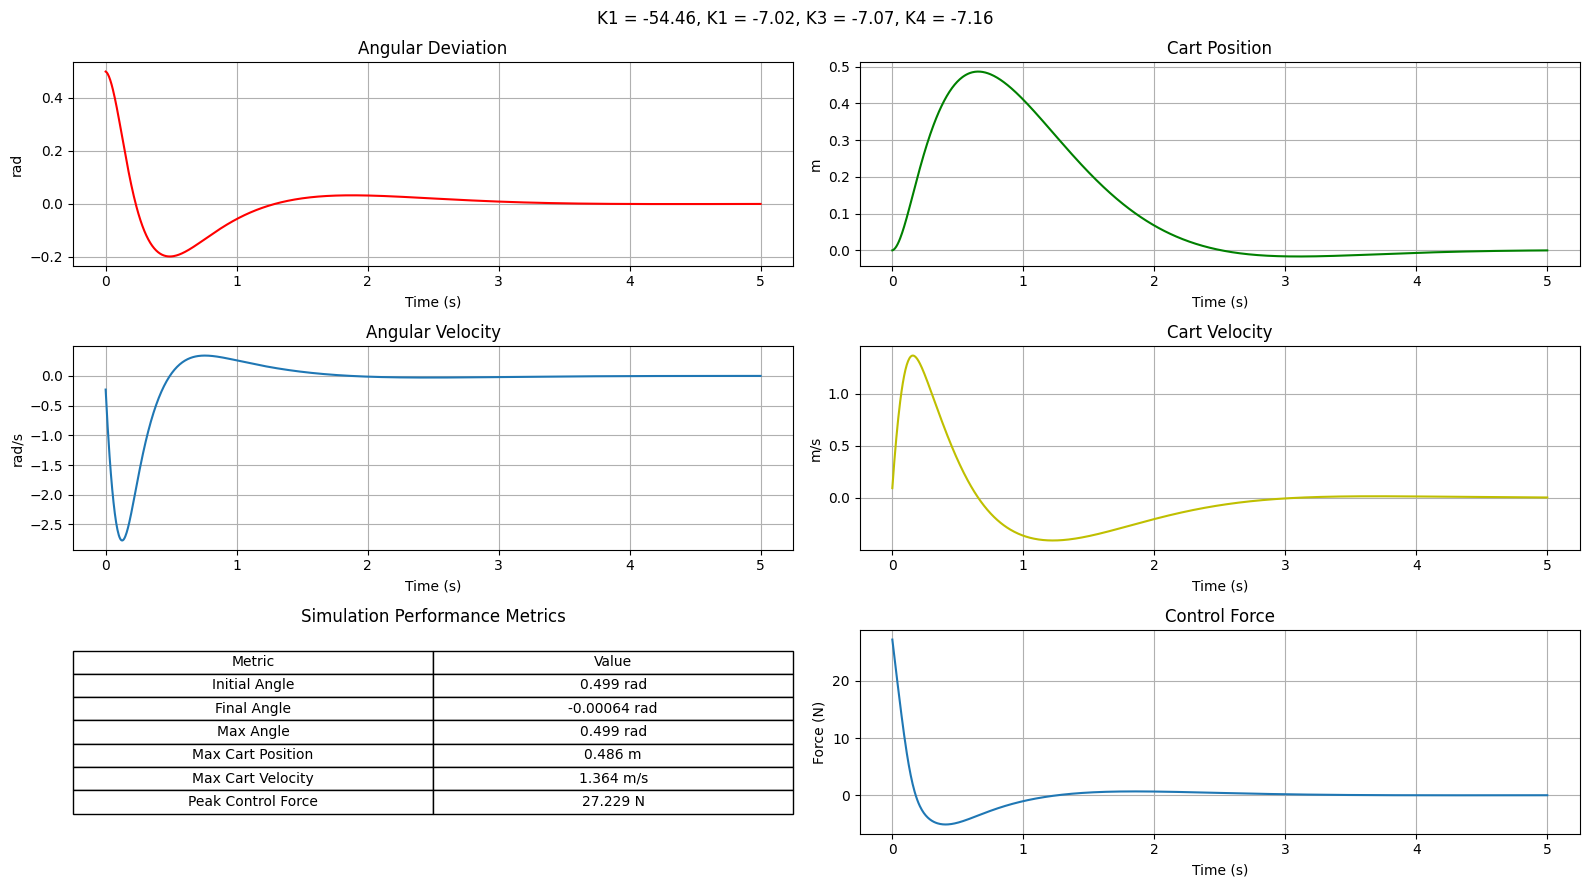

In [59]:
sim1 = CartPendulumSim()
Present(sim1)

##Section V: Summary

##References


1.   Lum, C. (2021). Introduction to Linear Quadratic Regulator (LQR) Control [Video]. YouTube. Available at: https://www.youtube.com/watch?v=wEevt2a4SKIBrigham

2. Tedrake, R. (2024). Linear Quadratic Regulators. Underactuated Robotics: Algorithms for Walking, Running, Swimming, Flying, and Manipulation (Ch. 8). Massachusetts Institute of Technology. Available at: https://underactuated.mit.edu/lqr.html